# Pipeline
This is where I build my pipeline.

## Idea
1. We will have two categories: Intersection and Address collisions (refer to `exploration.ipynb` for how I came to this conclusion).
2. We will separate the collisons dataset into two subsets, one for each category.

### Extract
1. Intersection and address collisions will have unrelated columns removed.
2. Intersection and address feature sets will also have unrelated columns removed, and will be transformed to contain only `id`, `description` and `geometry` columns.

### Transform
1. Intersection collisions will be mapped to the nearest intersection feature via spatial index, and string match score will be calculated via rapidfuzz
2. Address collisions will be mapped to the nearest address feature via spatial index, and string match score will be calculated via rapidfuzz

### Load
idk what happens now, I guess we just display the results.



In [1]:
# Importing necessary libraries

import geopandas as gpd
import pandas as pd
from shapely.geometry import shape
import json

address_pattern = r'^\d{1,5}\w?\s{0,2}\w+\s?\w+$'

# Function to fix multi point geoms
def to_point(geom):
    if geom.geom_type == "Point":
        return geom
    elif geom.geom_type == "MultiPoint":
        return list(geom.geoms)[0]  # take first point
    else:
        raise ValueError(f"Unsupported geometry type: {geom.geom_type}")


In [2]:
# Loading the collision data
collision_data = pd.read_csv("../data/raw/collisions.csv")

collision_data = collision_data[['collision_id', 'stname1', 'stname2', 'stname3', 'latitude', 'longitude']]

collision_data = gpd.GeoDataFrame(collision_data, geometry=gpd.points_from_xy(collision_data.longitude, collision_data.latitude), crs="EPSG:4326")
collision_data.to_csv("../data/processed/collisions.csv", index=False)
collision_data.head()

,collision_id,stname1,stname2,stname3,latitude,longitude,geometry
0,2006:893184,WOODBINE AVE,O CONNOR DR,NaN,43.699594,-79.318798,POINT (-79.3188 43.69959)
1,2006:893184,WOODBINE AVE,O CONNOR DR,NaN,43.699594,-79.318798,POINT (-79.3188 43.69959)
2,2006:893184,WOODBINE AVE,O CONNOR DR,NaN,43.699594,-79.318798,POINT (-79.3188 43.69959)
3,2006:893184,WOODBINE AVE,O CONNOR DR,NaN,43.699594,-79.318798,POINT (-79.3188 43.69959)
4,2006:893184,WOODBINE AVE,O CONNOR DR,NaN,43.699594,-79.318798,POINT (-79.3188 43.69959)


In [19]:
# Loading and processing intersection data
from shapely.geometry import shape
import json

# Initialize the intersection data
intersection_data = pd.read_csv('../data/raw/intersections.csv')

# Rename columns for consistency
intersection_data = intersection_data.rename(columns={'INTERSECTION_ID': 'feature_id', 'INTERSECTION_DESC': 'description'})

# Adding type column for use with address data
intersection_data['type'] = 'intersection'

# Extract only necessary columns
intersection_data = intersection_data[['feature_id', 'description', 'type', 'geometry']]

# Filter out rows where description is null or empty
intersection_data = intersection_data[intersection_data['description'].notna() & (intersection_data['description'].str.strip() != '')]

# Convert the geometry from WKT to shapely geometry
intersection_data["geometry"] = intersection_data["geometry"].apply(lambda x: shape(json.loads(x)))
intersection_data = gpd.GeoDataFrame(intersection_data, geometry='geometry', crs="EPSG:4326")

intersection_data['geometry'] = intersection_data['geometry'].apply(lambda x: to_point(x))

intersection_data.to_csv("../data/processed/intersections.csv", index=False)

intersection_data.head()

,feature_id,description,type,geometry
0,13469747,Grand Ave / Melrose St / Grand Avenue Park Trl,intersection,POINT (-79.49187 43.62171)
1,60002226,Grand Avenue Park Trl,intersection,POINT (-79.4903 43.62348)
2,60001952,Grand Avenue Park Trl,intersection,POINT (-79.49159 43.62268)
3,13469507,Mill Rd / Markland Dr,intersection,POINT (-79.57293 43.62729)
4,13469459,Markland Dr / Mountain Ash Crt,intersection,POINT (-79.57172 43.62819)


In [20]:
# Loading and processing address data
from shapely.geometry import shape
import json

address_data = pd.read_csv('../data/raw/addresses.csv')

# Renaming columns for consistency
address_data = address_data.rename(columns={"ADDRESS_POINT_ID": "feature_id", "ADDRESS_FULL": "description"})

# Adding type column for use with intersection data
address_data['type'] = 'address'

# Extracting necessary columns
address_data = address_data[["feature_id", "description", 'type', "geometry"]]

# Filter out rows where description is null or empty
address_data = address_data[address_data['description'].notna() & (address_data['description'].str.strip() != '')]

# Constructing geometry 
address_data["geometry"] = address_data["geometry"].apply(lambda x: shape(json.loads(x)))

address_data = gpd.GeoDataFrame(address_data, geometry="geometry", crs="EPSG:4326")

# Cleaning up multipoint geometry
address_data["geometry"] = address_data["geometry"].apply(lambda x: to_point(x))

address_data.to_csv("../data/processed/addresses.csv")

address_data.head()

/tmp/ipykernel_29254/3295527451.py:5: DtypeWarning: Columns (0: HI_NUM_SUF) have mixed types. Specify dtype option on import or set low_memory=False.
  address_data = pd.read_csv('../data/raw/addresses.csv')


,feature_id,description,type,geometry
0,2216175,1871 Davenport Rd,address,POINT (-79.45369 43.6704)
1,1020554,51 Neilson Dr,address,POINT (-79.5649 43.62991)
2,1033850,15 Stanmills Rd,address,POINT (-79.51649 43.62416)
3,30104725,98 Ossington Ave,address,POINT (-79.41982 43.64634)
4,492097,31 Briarfield Dr,address,POINT (-79.33824 43.73899)


In [21]:
# Separate address collisions from the rest of the collisions

address_collisions = collision_data[collision_data['stname1'].str.match(address_pattern, na=False) | collision_data['stname2'].str.match(address_pattern, na=False)]

address_collisions


,collision_id,stname1,stname2,stname3,latitude,longitude,geometry
65,2006:884310,460 CORONATION DR,NaN,NaN,43.765044,-79.170390,POINT (-79.17039 43.76504)
66,2006:884310,460 CORONATION DR,NaN,NaN,43.765044,-79.170390,POINT (-79.17039 43.76504)
67,2006:884310,460 CORONATION DR,NaN,NaN,43.765044,-79.170390,POINT (-79.17039 43.76504)
112,2006:888108,840 KENNEDY RD,NaN,NaN,43.735944,-79.269491,POINT (-79.26949 43.73594)
113,2006:888108,840 KENNEDY RD,NaN,NaN,43.735944,-79.269491,POINT (-79.26949 43.73594)
...,...,...,...,...,...,...,...
20417,2024:4001888169,60 CLEARVIEW HTS,NaN,1 m South of,43.692565,-79.481189,POINT (-79.48119 43.69257)
20429,2026:6000022030,93 TRETHEWEY DR,93 TRETHEWEY DR,20 m East of,43.693861,-79.480771,POINT (-79.48077 43.69386)
20438,2023:3002177373,690 GLENCAIRN AVE,NaN,NaN,43.710310,-79.437299,POINT (-79.4373 43.71031)
20439,2023:3002177373,690 GLENCAIRN AVE,NaN,NaN,43.710310,-79.437299,POINT (-79.4373 43.71031)


In [22]:
intersection_collisions = collision_data[~(collision_data['stname1'].str.match(address_pattern, na=False) | collision_data['stname2'].str.match(address_pattern, na=False))]

intersection_collisions

,collision_id,stname1,stname2,stname3,latitude,longitude,geometry
0,2006:893184,WOODBINE AVE,O CONNOR DR,NaN,43.699594,-79.318798,POINT (-79.3188 43.69959)
1,2006:893184,WOODBINE AVE,O CONNOR DR,NaN,43.699594,-79.318798,POINT (-79.3188 43.69959)
2,2006:893184,WOODBINE AVE,O CONNOR DR,NaN,43.699594,-79.318798,POINT (-79.3188 43.69959)
3,2006:893184,WOODBINE AVE,O CONNOR DR,NaN,43.699594,-79.318798,POINT (-79.3188 43.69959)
4,2006:893184,WOODBINE AVE,O CONNOR DR,NaN,43.699594,-79.318798,POINT (-79.3188 43.69959)
...,...,...,...,...,...,...,...
20450,2025:5000721646,LAKE SHORE BLVD W,FIFTH ST,5 m East of,43.601263,-79.503003,POINT (-79.503 43.60126)
20451,2025:5000721646,LAKE SHORE BLVD W,FIFTH ST,5 m East of,43.601263,-79.503003,POINT (-79.503 43.60126)
20452,2025:5000721646,LAKE SHORE BLVD W,FIFTH ST,5 m East of,43.601263,-79.503003,POINT (-79.503 43.60126)
20453,2025:5000721646,LAKE SHORE BLVD W,FIFTH ST,5 m East of,43.601263,-79.503003,POINT (-79.503 43.60126)


In [23]:
# Reproject collisions and features to common CRS

intersection_data = intersection_data.to_crs(epsg=32617)
intersection_collisions = intersection_collisions.to_crs(epsg=32617)

address_data = address_data.to_crs(epsg=32617)
address_collisions = address_collisions.to_crs(epsg=32617)

In [24]:
# Merge collision and feature dataset by distance using spatial index

# Intersections
intersection_merged = gpd.sjoin_nearest(intersection_collisions, intersection_data, distance_col="distance")

intersection_merged['stname2'] = intersection_merged['stname2'].fillna("")

intersection_merged['location_desc'] = (intersection_merged['stname1'] + " " + intersection_merged['stname2']).str.lower()

intersection_merged['description'] = intersection_merged['description'].str.lower().str.replace("/", "")

# Addresses
address_merged = gpd.sjoin_nearest(address_collisions, address_data, distance_col="distance")

# Filling null values with empty string to help with concat
address_merged['stname2'] = address_merged['stname2'].fillna("")

address_merged['location_desc'] = (address_merged['stname1'] + " " + address_merged["stname2"]).str.lower()

address_merged['description'] = address_merged['description'].str.lower()

address_merged.head()

,collision_id,stname1,stname2,stname3,latitude,longitude,geometry,index_right,feature_id,description,type,distance,location_desc
65,2006:884310,460 CORONATION DR,,NaN,43.765044,-79.170390,POINT (647266.074 4847404.011),476765,323006,460 coronation dr,address,63.713216,460 coronation dr
66,2006:884310,460 CORONATION DR,,NaN,43.765044,-79.170390,POINT (647266.074 4847404.011),476765,323006,460 coronation dr,address,63.713216,460 coronation dr
67,2006:884310,460 CORONATION DR,,NaN,43.765044,-79.170390,POINT (647266.074 4847404.011),476765,323006,460 coronation dr,address,63.713216,460 coronation dr
112,2006:888108,840 KENNEDY RD,,NaN,43.735944,-79.269491,POINT (639356.87 4844000.551),155749,2905369,836 kennedy rd,address,32.517276,840 kennedy rd
113,2006:888108,840 KENNEDY RD,,NaN,43.735944,-79.269491,POINT (639356.87 4844000.551),155749,2905369,836 kennedy rd,address,32.517276,840 kennedy rd


In [25]:
# Compute string similarity scores

from rapidfuzz import fuzz

# Intersections
intersection_merged['match_score'] = [fuzz.token_sort_ratio(loc, desc) for loc, desc in zip(intersection_merged['location_desc'], intersection_merged['description'])]

# Addresses
address_merged['match_score'] = [fuzz.token_sort_ratio(loc, desc) for loc, desc in zip(address_merged['location_desc'], address_merged['description'])]

In [33]:
# Let's see some intersection collision stats!
print("Intersections\n", intersection_merged['match_score'].describe(), "\n")

print(intersection_merged['distance'].describe(), "\n")

Intersections
 count    19918.000000
mean        84.867573
std         20.071574
min         10.526316
25%         71.428571
50%        100.000000
75%        100.000000
max        100.000000
Name: match_score, dtype: float64 

count    19918.000000
mean        23.029100
std         34.788008
min          0.069788
25%          3.474451
50%          8.457966
75%         29.822289
max        411.611570
Name: distance, dtype: float64 



In [32]:
# Let's see some address collision stats!
print("Addresses\n", address_merged['match_score'].describe(), "\n")
print(address_merged['distance'].describe())


Addresses
 count    1286.000000
mean       81.272320
std        19.496454
min        19.354839
25%        76.470588
50%        87.500000
75%        93.333333
max       100.000000
Name: match_score, dtype: float64 

count    1286.000000
mean       36.923876
std        27.481132
min         4.460519
25%        21.708875
50%        27.647894
75%        42.699748
max       233.879434
Name: distance, dtype: float64


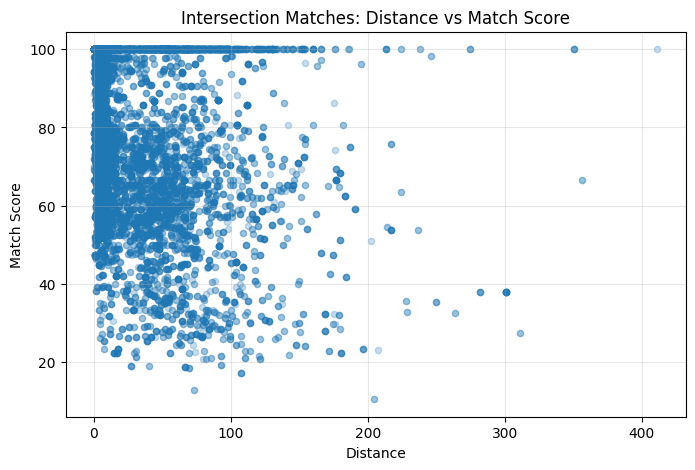

In [27]:
ax = intersection_merged.plot(
    kind="scatter",
    x="distance",
    y="match_score",
    figsize=(8, 5),
    alpha=0.25
)

ax.set_title("Intersection Matches: Distance vs Match Score")
ax.set_xlabel("Distance")
ax.set_ylabel("Match Score")
ax.grid(True, alpha=0.3)

In [34]:
intersection_merged[(intersection_merged['match_score'] > 70) & (intersection_merged['distance'] < 20)]

,collision_id,stname1,stname2,stname3,latitude,longitude,geometry,index_right,feature_id,description,type,distance,location_desc,match_score
8,2006:909646,DANFORTH AVE,WEST LYNN AVE,NaN,43.684873,-79.316189,POINT (635711.468 4838250.902),19154,13460669,danforth ave west lynn ave,intersection,8.191054,danforth ave west lynn ave,100.0
9,2006:909646,DANFORTH AVE,WEST LYNN AVE,NaN,43.684873,-79.316189,POINT (635711.468 4838250.902),19154,13460669,danforth ave west lynn ave,intersection,8.191054,danforth ave west lynn ave,100.0
10,2006:909646,DANFORTH AVE,WEST LYNN AVE,NaN,43.684873,-79.316189,POINT (635711.468 4838250.902),19154,13460669,danforth ave west lynn ave,intersection,8.191054,danforth ave west lynn ave,100.0
11,2006:909646,DANFORTH AVE,WEST LYNN AVE,NaN,43.684873,-79.316189,POINT (635711.468 4838250.902),19154,13460669,danforth ave west lynn ave,intersection,8.191054,danforth ave west lynn ave,100.0
12,2006:909646,DANFORTH AVE,WEST LYNN AVE,NaN,43.684873,-79.316189,POINT (635711.468 4838250.902),19154,13460669,danforth ave west lynn ave,intersection,8.191054,danforth ave west lynn ave,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20449,2025:5000721646,LAKE SHORE BLVD W,FIFTH ST,5 m East of,43.601263,-79.503003,POINT (620821.944 4828676.235),2920,13470434,lake shore blvd w fifth st,intersection,2.221683,lake shore blvd w fifth st,100.0
20450,2025:5000721646,LAKE SHORE BLVD W,FIFTH ST,5 m East of,43.601263,-79.503003,POINT (620821.944 4828676.235),2920,13470434,lake shore blvd w fifth st,intersection,2.221683,lake shore blvd w fifth st,100.0
20451,2025:5000721646,LAKE SHORE BLVD W,FIFTH ST,5 m East of,43.601263,-79.503003,POINT (620821.944 4828676.235),2920,13470434,lake shore blvd w fifth st,intersection,2.221683,lake shore blvd w fifth st,100.0
20452,2025:5000721646,LAKE SHORE BLVD W,FIFTH ST,5 m East of,43.601263,-79.503003,POINT (620821.944 4828676.235),2920,13470434,lake shore blvd w fifth st,intersection,2.221683,lake shore blvd w fifth st,100.0


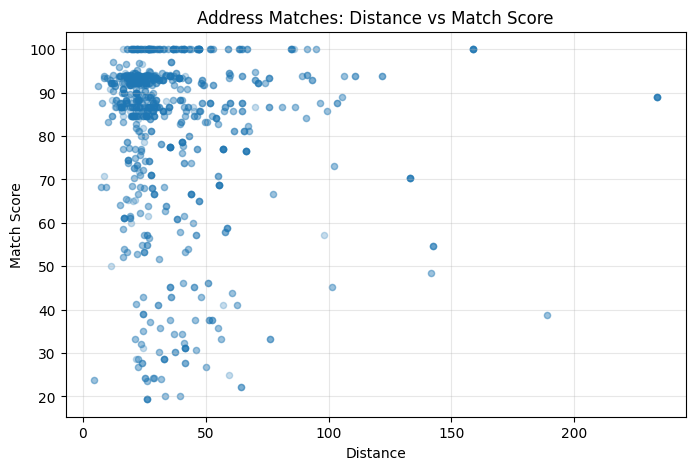

In [31]:
ax = address_merged.plot(
    kind="scatter",
    x="distance",
    y="match_score",
    figsize=(8, 5),
    alpha=0.25
)

ax.set_title("Address Matches: Distance vs Match Score")
ax.set_xlabel("Distance")
ax.set_ylabel("Match Score")
ax.grid(True, alpha=0.3)